# Plot benchmark results

In this notebook can be used to generate benchmark environments as found in the ABCI paper.

In [9]:

%reload_ext autoreload
%autoreload 2
import os

import matplotlib.pyplot as plt

import sys
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), '..')))
sys.path.append(os.path.abspath(os.getcwd()))

from src.utils.plotting import init_plot_style, Simulation

init_plot_style()

In [10]:
# the simulations you want to plot/compare
simulations_test = []
num_exp = 50

##############################################################################
# ablation N train samples
##############################################################################

# BA NL
env_name = 'BarabasiAlbert'


if True:
    results_dir = f'/ceph/home/TUG/epfeiler-tug/abci-arco-gp/results/BarabasiAlbert/20_nodes_debug/'
    simulations_test.append(Simulation(results_dir + '20260215_113930_test-arcogp-random', num_exp,
                                plot_kwargs={'label': 'random', 'marker': 's', 'c': 'Plum',
                                            'markersize': 10}))
    simulations_test.append(Simulation(results_dir + '20260215_114002_test-arcogp-random_bs1', num_exp,
                                plot_kwargs={'label': 'Random BS1', 'marker': 's', 'c': 'r',
                                            'markersize': 10}))
    simulations_test.append(Simulation(results_dir + '20260215_114017_test-arcogp-random_bs15', num_exp,
                                plot_kwargs={'label': 'Random BS15', 'marker': 's', 'c': 'b',
                                            'markersize': 10}))

if False:
    results_dir = f'/ceph/home/TUG/epfeiler-tug/abci-arco-gp/results/BarabasiAlbert/10_nodes_50_train/'
    simulations_test.append(Simulation(results_dir + '20260117_181955_test-arcogp-random', num_exp,
                                plot_kwargs={'label': 'Random', 'marker': 's', 'c': 'Plum',
                                            'markersize': 10}))
    simulations_test.append(Simulation(results_dir + '20260117_181920_test-arcogp-random-fixed-value', num_exp,
                                plot_kwargs={'label': 'Random Fixed', 'marker': 's', 'c': 'r',
                                            'markersize': 10}))

#No such file or directory: '/ceph/home/TUG/epfeiler-tug/abci-arco-gp/results/BarabasiAlbert/10_nodes_50_train20260117_140300_test-arcogp-random/'
#                            /ceph/home/TUG/epfeiler-tug/abci-arco-gp/results/BarabasiAlbert/10_nodes_50_train/20260117_140300_test-arcogp-random


Initialise plotting setup and load simulation results

In [11]:

# the stats to extract from the simulation results
stats_names = ['enum_edges', 'aaid', 'paid', 'oset_aid', 'order_aid', 'aaid_cpdag', 'paid_cpdag', 'oset_aid_cpdag',
               'eshd', 'auroc', 'auprc', 'etpr', 'etnr', 'ef1',
               'eshd_cpdag', 'auroc_cpdag', 'auprc_cpdag', 'etpr_cpdag', 'etnr_cpdag', 'ef1_cpdag'
               ]

# load results
for sim in simulations_test:
    sim.load_results(result_type="default")

# plot setup
init_plot_style()

save_plots = True
dpi = 400
fig_format = 'pdf'
fig_dir = '../figures/'
figdate = '20261801'
fig_name = f'{env_name}-10-nodes-50-train'

os.makedirs(fig_dir, exist_ok=True)

# axis labels for the given stats
stat_labels = {'enum_edges': '\#Edges', 'aaid': 'A-AID', 'paid': 'P-AID', 'oset_aid': 'OSET-AID',
               'order_aid': 'A-AID (CO)',
               'aaid_cpdag': 'A-AID (CPDAG)', 'paid_cpdag': 'P-AID (CPDAG)', 'oset_aid_cpdag': 'OSET-AID (CPDAG)',
               'eshd': 'ESHD', 'auroc': 'AUROC', 'auprc': 'AUPRC', 'etpr': 'TPR', 'etnr': 'TNR', 'ef1': 'F1',
               'eshd_cpdag': 'ESHD', 'auroc_cpdag': 'AUROC', 'auprc_cpdag': 'AUPRC', 'etpr_cpdag': 'TPR',
               'etnr_cpdag': 'TNR', 'ef1_cpdag': 'F1',
               }

# file identifier token for the given stats
stat_tokens = {'eshd': 'ESHD', 'eshd_cpdag': 'ESHD (CPDAG)',
               'auroc': 'AUROC', 'auprc': 'AUPRC', 'etpr': 'TPR', 'etnr': 'TNR', 'ef1': 'F1',
               'aaid': 'AAID'
               }



Num exp found 80 does not match num exp set 50
Num exp found 26 does not match num exp set 50
Num exp found 58 does not match num exp set 50
Num exp found 22 does not match num exp set 50
Num exp found 23 does not match num exp set 50
Num exp found 75 does not match num exp set 50
Num exp found 85 does not match num exp set 50
Num exp found 67 does not match num exp set 50
Num exp found 51 does not match num exp set 50
Num exp found 12 does not match num exp set 50
Num exp found 85 does not match num exp set 50
Num exp found 60 does not match num exp set 50
Num exp found 31 does not match num exp set 50
Num exp found 72 does not match num exp set 50
Num exp found 19 does not match num exp set 50
Num exp found 40 does not match num exp set 50
Num exp found 11 does not match num exp set 50
Num exp found 86 does not match num exp set 50
Num exp found 66 does not match num exp set 50
Num exp found 51 does not match num exp set 50
Num exp found 73 does not match num exp set 50
Num exp found

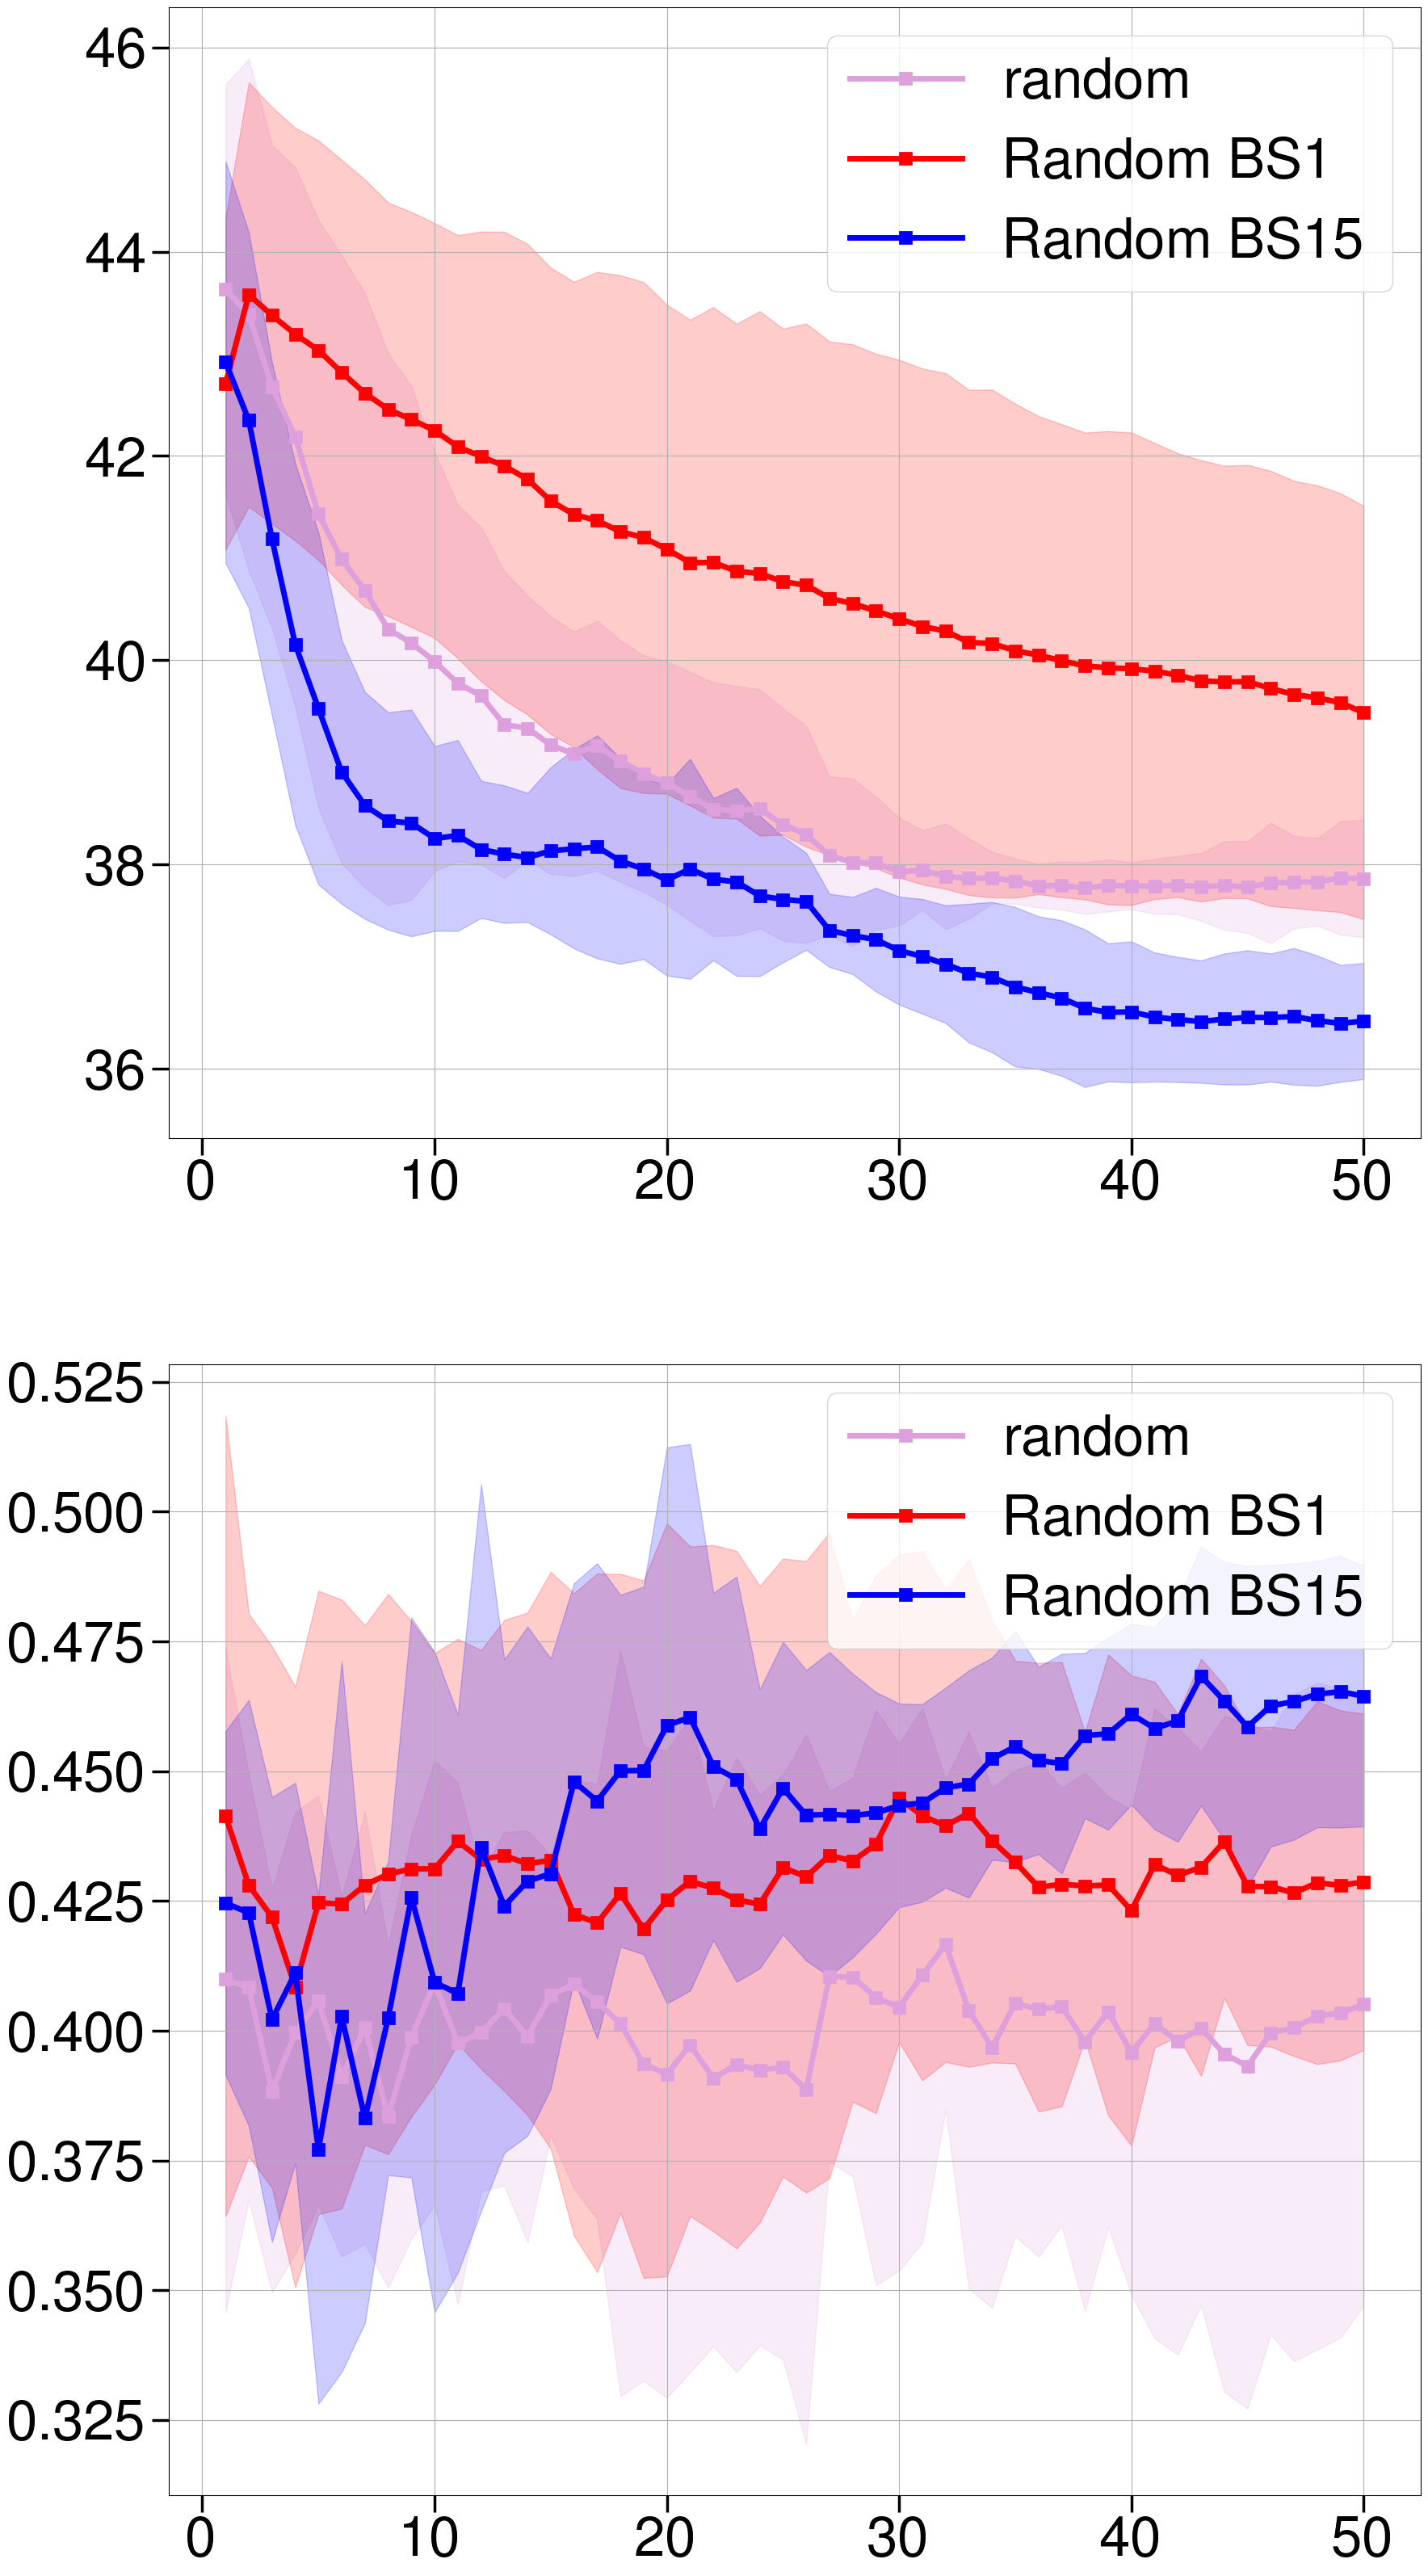

<Figure size 1200x900 with 0 Axes>

In [12]:
stat_names = [
    #'aaid',
    'eshd',
    #'etpr',
    #'etnr',
    'auroc'
]

fix, axs = plt.subplots(len(stat_names),1, figsize=(20,20*len(stat_names)))

for sim in simulations_test:
    for stat_idx, stat_name in enumerate(stat_names):
        if len(stat_names) > 1:
            ax = axs[stat_idx]
        else:
            ax = axs
        ax.grid(True)
        sim.plot_simulation_data(ax=ax, stat_name=stat_name)

for stat_idx, stat_name in enumerate(stat_names):
    if len(stat_names) > 1:
        ax = axs[stat_idx]
    else:
        ax = axs
    ax.legend()


plt.show()
plt.savefig("../figures/BarabasiAlbert-5_nodes_90_AUROC.png")

In [13]:
# simulations = simulations_test

# sim_ba = []
# sim_er = []
# num_sim = int(len(simulations_test) / 2)
# num_sim
# print(f"num_sim = {num_sim}")
# for i in range(num_sim):
#     sim_ba.append(simulations[i])
#     sim_er.append(simulations[i + num_sim])

# print(len(sim_ba), len(sim_er))

# stat_names = [
#     'aaid',
#     'eshd',
#     # 'etpr',
#     # 'etnr',
#     'auroc'
# ]

# boxplot = False
# for stat_name in stat_names:
#     print(f'Generating plot for stat {stat_name}', flush=True)
#     # plot stats over experiments
#     ax = plt.figure(figsize=(52, 10)).gca()
#     data_ba = [sim.stats[stat_name][:, -1] for sim in sim_ba if
#                stat_name in sim.stats and (sim.plot_kwargs['label'] != 'PC' or stat_name != 'aaid')]
#     data_er = [sim.stats[stat_name][:, -1] for sim in sim_er if
#                stat_name in sim.stats and (sim.plot_kwargs['label'] != 'PC' or stat_name != 'aaid')]
#     labels = [sim.plot_kwargs['label'] for sim in sim_ba]

#     if stat_name == 'aaid':
#         data_ba.append(data_ba[-1].numpy())
#         data_er.append(data_er[-1].numpy())

#     # generate positions
#     gap = 1.8
#     intra = 0.8
#     cursor = 0
#     pos_ba = []
#     pos_er = []
#     ticks = []
#     for i in range(num_sim):
#         pos_ba.append(cursor)
#         pos_er.append(cursor + intra)
#         ticks.append(cursor + intra/2.)
#         cursor += intra + gap
    
#     parts_ba = ax.violinplot(data_ba, pos_ba, showmedians=True, widths=0.5)
#     parts_er = ax.violinplot(data_er, pos_er, showmedians=True, widths=0.5)

#     ax.set_xticks(ticks, labels=labels)

#     for i in range(num_sim):
#         parts_er['bodies'][i].set_color('#E67E22')

#     for part in ['cmedians', 'cmaxes', 'cmins', 'cbars']:
#         # segments = parts_er[part].get_segments()
#         parts_er[part].set_color('#E67E22')

#     if stat_name == 'aaid':
#         parts_ba['bodies'][-1].set_alpha(0)
#         parts_er['bodies'][-1].set_alpha(0)
#         for part in ['cmedians', 'cmaxes', 'cmins', 'cbars']:
#             new_segs = [s for s in parts_ba[part].get_segments()]
#             new_segs = new_segs[:-1]
#             parts_ba[part].set_segments(new_segs)

#             new_segs = [s for s in parts_er[part].get_segments()]
#             new_segs = new_segs[:-1]
#             parts_er[part].set_segments(new_segs)

#         plt.text(0.93, 0.5, 'N/A', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    
#     if stat_name == 'eshd':
#         plt.ylim([-3,85])
#         plt.text(0.325, 0.5, '>125', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        
#     plt.ylabel(stat_labels[stat_name])
#     plt.tight_layout()

#     if save_plots:
#         plt.savefig(fig_dir + f'{figdate}-{stat_tokens[stat_name]}.{fig_format}', dpi=dpi, bbox_inches='tight')

In [14]:

# # the stats to extract from the simulation results
# stats_names = ['enum_edges', 'aaid', 'paid', 'oset_aid', 'order_aid', 'aaid_cpdag', 'paid_cpdag', 'oset_aid_cpdag',
#                'eshd', 'auroc', 'auprc', 'etpr', 'etnr', 'ef1',
#                'eshd_cpdag', 'auroc_cpdag', 'auprc_cpdag', 'etpr_cpdag', 'etnr_cpdag', 'ef1_cpdag'
#                ]

# # load results
# for sim in simulations:
#     sim.load_results(stats_names)

# # plot setup
# init_plot_style()

# save_plots = True
# dpi = 400
# fig_format = 'pdf'
# fig_dir = '../figures/'
# figdate = '20241011'
# fig_name = f'{env_name}-20-nodes-200-train'

# os.makedirs(fig_dir, exist_ok=True)

# # axis labels for the given stats
# stat_labels = {'enum_edges': '\#Edges', 'aaid': 'A-AID', 'paid': 'P-AID', 'oset_aid': 'OSET-AID',
#                'order_aid': 'A-AID (CO)',
#                'aaid_cpdag': 'A-AID (CPDAG)', 'paid_cpdag': 'P-AID (CPDAG)', 'oset_aid_cpdag': 'OSET-AID (CPDAG)',
#                'eshd': 'ESHD', 'auroc': 'AUROC', 'auprc': 'AUPRC', 'etpr': 'TPR', 'etnr': 'TNR', 'ef1': 'F1',
#                'eshd_cpdag': 'ESHD', 'auroc_cpdag': 'AUROC', 'auprc_cpdag': 'AUPRC', 'etpr_cpdag': 'TPR',
#                'etnr_cpdag': 'TNR', 'ef1_cpdag': 'F1',
#                }

# # file identifier token for the given stats
# stat_tokens = {'eshd': 'ESHD', 'eshd_cpdag': 'ESHD (CPDAG)',
#                'auroc': 'AUROC', 'auprc': 'AUPRC', 'etpr': 'TPR', 'etnr': 'TNR', 'ef1': 'F1',
#                'aaid': 'AAID'
#                }



In [15]:

#ba + er
sim_ba = []
sim_er = []
num_sim = int(len(simulations) / 2)
for i in range(num_sim):
    sim_ba.append(simulations[i])
    sim_er.append(simulations[i + num_sim])

print(len(sim_ba), len(sim_er))


NameError: name 'simulations' is not defined

Generating plot for stat aaid


NameError: name 'sim_ba' is not defined

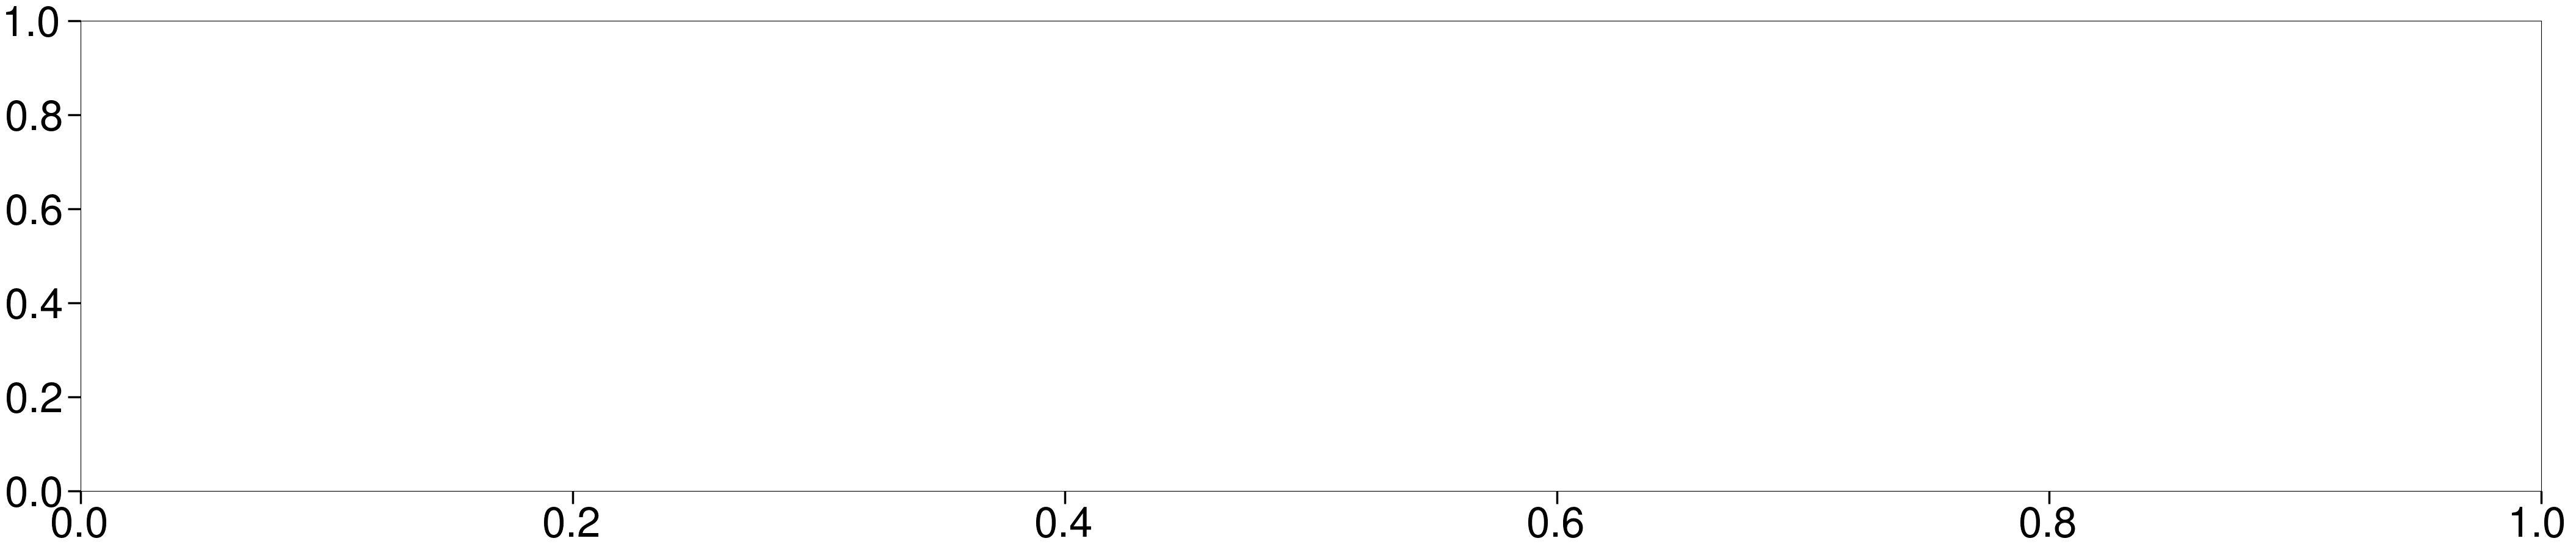

In [ ]:


stat_names = [
    'aaid',
    'eshd',
    # 'etpr',
    # 'etnr',
    # 'auroc'
]

boxplot = False
for stat_name in stat_names:
    print(f'Generating plot for stat {stat_name}', flush=True)
    # plot stats over experiments
    ax = plt.figure(figsize=(52, 10)).gca()
    data_ba = [sim.stats[stat_name][:, -1] for sim in sim_ba if
               stat_name in sim.stats and (sim.plot_kwargs['label'] != 'PC' or stat_name != 'aaid')]
    data_er = [sim.stats[stat_name][:, -1] for sim in sim_er if
               stat_name in sim.stats and (sim.plot_kwargs['label'] != 'PC' or stat_name != 'aaid')]
    labels = [sim.plot_kwargs['label'] for sim in sim_ba]

    if stat_name == 'aaid':
        data_ba.append(data_ba[-1].numpy())
        data_er.append(data_er[-1].numpy())

    # generate positions
    gap = 1.8
    intra = 0.8
    cursor = 0
    pos_ba = []
    pos_er = []
    ticks = []
    for i in range(num_sim):
        pos_ba.append(cursor)
        pos_er.append(cursor + intra)
        ticks.append(cursor + intra/2.)
        cursor += intra + gap
    
    parts_ba = ax.violinplot(data_ba, pos_ba, showmedians=True, widths=0.5)
    parts_er = ax.violinplot(data_er, pos_er, showmedians=True, widths=0.5)

    ax.set_xticks(ticks, labels=labels)

    for i in range(num_sim):
        parts_er['bodies'][i].set_color('#E67E22')

    for part in ['cmedians', 'cmaxes', 'cmins', 'cbars']:
        # segments = parts_er[part].get_segments()
        parts_er[part].set_color('#E67E22')

    if stat_name == 'aaid':
        parts_ba['bodies'][-1].set_alpha(0)
        parts_er['bodies'][-1].set_alpha(0)
        for part in ['cmedians', 'cmaxes', 'cmins', 'cbars']:
            new_segs = [s for s in parts_ba[part].get_segments()]
            new_segs = new_segs[:-1]
            parts_ba[part].set_segments(new_segs)

            new_segs = [s for s in parts_er[part].get_segments()]
            new_segs = new_segs[:-1]
            parts_er[part].set_segments(new_segs)

        plt.text(0.93, 0.5, 'N/A', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    
    if stat_name == 'eshd':
        plt.ylim([-3,85])
        plt.text(0.325, 0.5, '>125', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
        
    plt.ylabel(stat_labels[stat_name])
    plt.tight_layout()

    if save_plots:
        plt.savefig(fig_dir + f'{figdate}-{stat_tokens[stat_name]}.{fig_format}', dpi=dpi, bbox_inches='tight')

Plot single stat box plot for results after the final experiment.

Generating plot for stat aaid


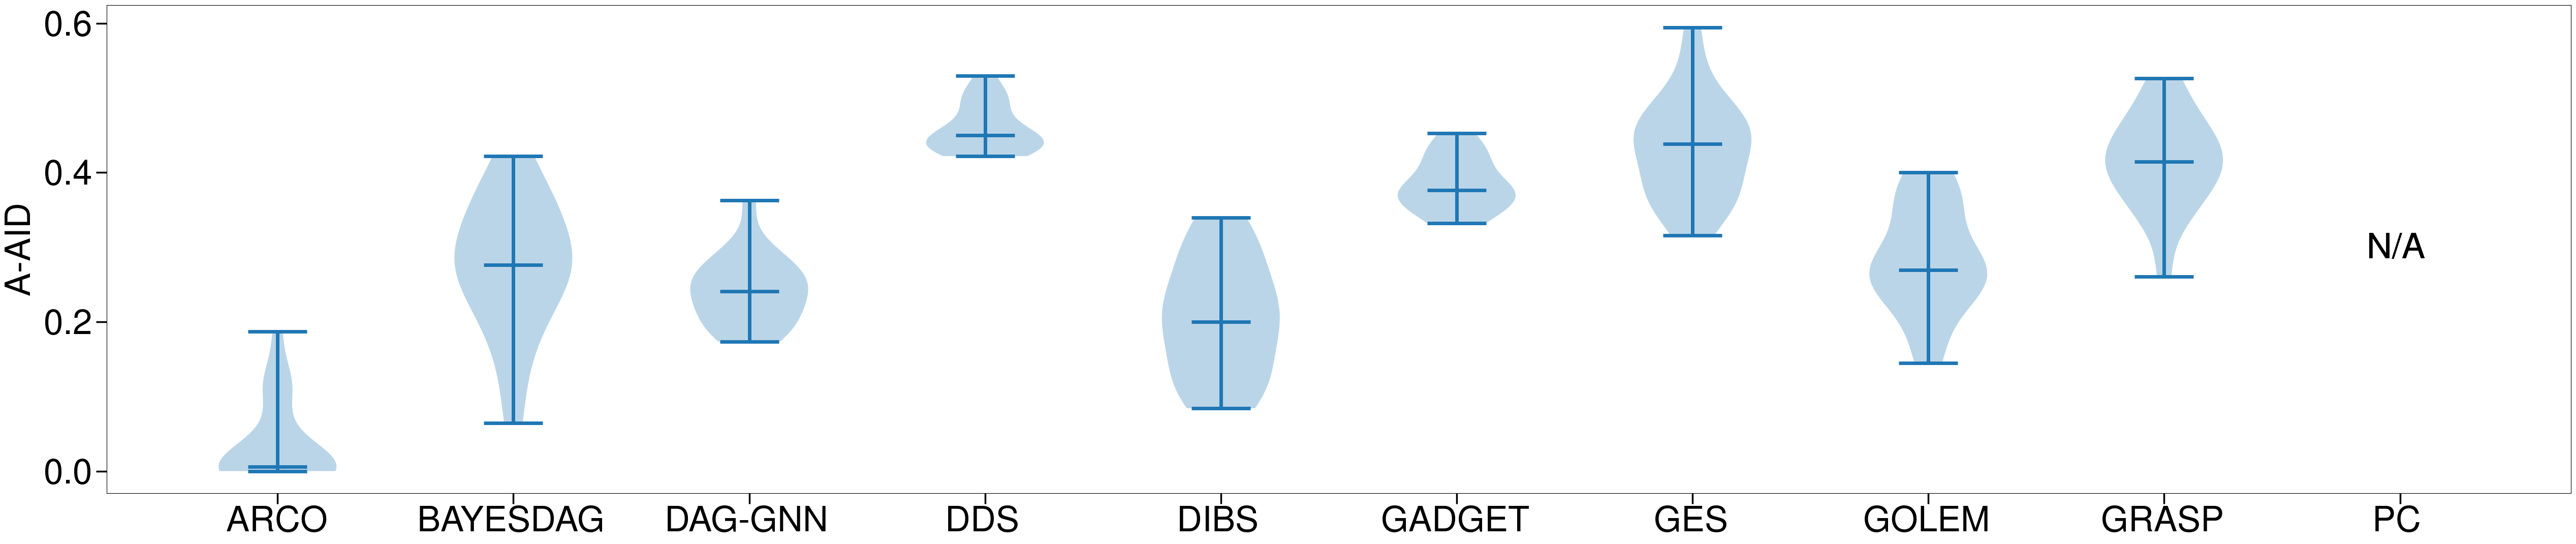

In [ ]:
import numpy as np

stat_names = [
    'aaid',
    # 'eshd',
    # 'etpr',
    # 'etnr',
    # 'auroc'
]

boxplot = False
for stat_name in stat_names:
    print(f'Generating plot for stat {stat_name}', flush=True)
    # plot stats over experiments
    ax = plt.figure(figsize=(52, 12)).gca()
    data = [sim.stats[stat_name][:, -1] for sim in simulations if
            stat_name in sim.stats and (sim.plot_kwargs['label'] != 'PC' or stat_name != 'aaid')]
    labels = [sim.plot_kwargs['label'] for sim in simulations if
              stat_name in sim.stats and (sim.plot_kwargs['label'] != 'PC' or stat_name != 'aaid')]

    if boxplot:
        ax.boxplot(data, notch=False, showmeans=False, labels=labels)
        if stat_name == 'aaid':
            data.append(np.nan)
            labels.append('PC')
            plt.text(0.95, 0.5, 'N/A', horizontalalignment='center', verticalalignment='center', transform=ax.transAxes)
    else:
        if stat_name == 'aaid':
            data.append(data[-1].numpy())
            labels.append('PC')

        parts = ax.violinplot(data, showmedians=True)
        if stat_name == 'aaid':
            parts['bodies'][-1].set_alpha(0)
            for part in ['cmedians', 'cmaxes', 'cmins', 'cbars']:
                new_segs = [s for s in parts[part].get_segments()]
                new_segs = new_segs[:-1]
                parts[part].set_segments(new_segs)
                plt.text(0.93, 0.5, 'N/A', horizontalalignment='center', verticalalignment='center',
                         transform=ax.transAxes)

        ax.set_xticks([i + 1 for i in range(len(labels))], labels=labels)

    plt.ylabel(stat_labels[stat_name])
    plt.tight_layout()

    if save_plots:
        plt.savefig(fig_dir + f'{figdate}-{fig_name}-{stat_tokens[stat_name]}.{fig_format}', dpi=dpi,
                    bbox_inches='tight')


Plot multiple stats box plot for results after the final experiment.

# Plot Post-Processing Results: CO-Weights

In [ ]:

import os
import pandas as pd
import torch


def load_co_weights(results_dir: str):
    files = [os.path.abspath(entry) for entry in os.scandir(results_dir) if
             entry.is_file() and os.path.basename(entry)[-13:] == 'coweights.csv']
    num_files = len(files)

    if num_files == 0:
        print(f'No stats files found in {results_dir}.')
        return None

    cum_weights = []
    for file in files:
        df = pd.read_csv(file)

        # avg_num_unique = df['num_unique'].to_numpy().mean()
        # print(f'Average number of unique cos: {avg_num_unique}')

        co_weights = torch.tensor(df.drop(columns=['num_unique']).to_numpy())
        num_draws, num_mc_cos = co_weights.shape
        # print(f'{num_mc_cos} MC COs in {num_draws} draws.')

        sorted_weights = torch.sort(co_weights.exp(), dim=1)[0]
        cum_weights.append(torch.cumsum(sorted_weights, dim=1).mean(dim=0))

    cum_weights = torch.stack(cum_weights)
    assert cum_weights.shape == (num_files, num_mc_cos)
    return cum_weights


resdirs = {'COM-EX-GP': '../results/ErdosRenyi/20_nodes_100_train_normalised/20240201_2341_bci-ctom-ex/',
           'COM-SIMPLE-EX-GP': '../results/ErdosRenyi/20_nodes_100_train_normalised/20240204_1033_bci-ctom-ex-simple/',
           'COM-EX-LINEAR-GP': '../results/ErdosRenyi/20_nodes_100_train_linear/20240203_1617_bci-ctom-ex-linear/',
           'COM-SIMPLE-EX-LINEAR-GP': '../results/ErdosRenyi/20_nodes_100_train_linear/20240207_1044_bci-ctom-ex-simple-linear/', }
cum_weights = {key: load_co_weights(resdir) for key, resdir in resdirs.items()}

plt.figure()
for key, weights in cum_weights.items():
    plt.plot(weights.mean(dim=0), label=key)
plt.plot([0, 100], [0, 1], 'r--')
plt.legend()
plt.tight_layout()



# Post-Processing Results: Estimator Variance with CO Samples

In [ ]:
# the simulations you want to plot/compare
simulations = []

env_name = 'ErdosRenyi'
results_dir = f'../results/{env_name}/20_nodes_100_train_normalised/'
simulations.append(Simulation(results_dir + '20240201_2341_bci-ctom-ex', num_experiments=1,
                              plot_kwargs={'label': 'COM-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
simulations.append(Simulation(results_dir + '20240201_2341_bci-ctom-ex', num_experiments=5,
                              plot_kwargs={'label': 'COM-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
simulations.append(Simulation(results_dir + '20240201_2341_bci-ctom-ex', num_experiments=10,
                              plot_kwargs={'label': 'COM-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
simulations.append(Simulation(results_dir + '20240201_2341_bci-ctom-ex', num_experiments=20,
                              plot_kwargs={'label': 'COM-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
simulations.append(Simulation(results_dir + '20240201_2341_bci-ctom-ex', num_experiments=50,
                              plot_kwargs={'label': 'COM-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
simulations.append(Simulation(results_dir + '20240201_2341_bci-ctom-ex', num_experiments=100,
                              plot_kwargs={'label': 'COM-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))

# simulations.append(Simulation(results_dir + '20240204_1033_bci-ctom-ex-simple', num_experiments=1,
#                               plot_kwargs={'label': 'COM-SIMPLE-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
# simulations.append(Simulation(results_dir + '20240204_1033_bci-ctom-ex-simple', num_experiments=5,
#                               plot_kwargs={'label': 'COM-SIMPLE-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
# simulations.append(Simulation(results_dir + '20240204_1033_bci-ctom-ex-simple', num_experiments=10,
#                               plot_kwargs={'label': 'COM-SIMPLE-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
# simulations.append(Simulation(results_dir + '20240204_1033_bci-ctom-ex-simple', num_experiments=20,
#                               plot_kwargs={'label': 'COM-SIMPLE-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
# simulations.append(Simulation(results_dir + '20240204_1033_bci-ctom-ex-simple', num_experiments=50,
#                               plot_kwargs={'label': 'COM-SIMPLE-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
# simulations.append(Simulation(results_dir + '20240204_1033_bci-ctom-ex-simple', num_experiments=100,
#                               plot_kwargs={'label': 'COM-SIMPLE-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))

# env_name = 'BarabasiAlbert'
# results_dir = f'../results/{env_name}/20_nodes_100_train_normalised/'
# simulations.append(Simulation(results_dir + '20240201_2356_bci-ctom-ex', num_exp,
#                               plot_kwargs={'label': 'COM-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
# simulations.append(Simulation(results_dir + '20240204_1032_bci-ctom-ex-simple', num_exp,
#                               plot_kwargs={'label': 'COM-SIMPLE-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))


# env_name = 'ErdosRenyi'
# results_dir = f'../results/{env_name}/20_nodes_100_train_linear/'
# simulations.append(Simulation(results_dir + '20240203_1617_bci-ctom-ex-linear', num_exp,
#                               plot_kwargs={'label': 'COM-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
# simulations.append(Simulation(results_dir + '20240207_1044_bci-ctom-ex-simple-linear', num_exp,
#                               plot_kwargs={'label': 'COM-SIMPLE-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))


# env_name = 'BarabasiAlbert'
# results_dir = f'../results/{env_name}/20_nodes_100_train_linear/'
# simulations.append(Simulation(results_dir + '20240203_1621_bci-ctom-ex-linear', num_exp,
#                               plot_kwargs={'label': 'COM-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))
# simulations.append(Simulation(results_dir + '20240207_1044_bci-ctom-ex-simple-linear', num_exp,
#                               plot_kwargs={'label': 'COM-SIMPLE-EX-GP', 'marker': '*', 'c': 'CornflowerBlue'}))


# the stats to extract from the simulation results
stats_names = ['eshd', 'enum_edges', 'auroc', 'auprc', 'etpr', 'etnr', 'ef1',
               'eshd_skeleton', 'auroc_skeleton', 'auprc_skeleton', 'etpr_skeleton', 'etnr_skeleton', 'ef1_skeleton',
               #'observational_kld', 'avg_interventional_kld', 'query_kld', 'ecod', 'ecod_directed', 'ecod_rp', 'ecod_rp_directed',
               # 'auroc_co', 'auprc_co', 'etpr_co', 'etnr_co',
               'observational_rrmse', 'interventional_rrmse', 'observational_test_ll', 'interventional_test_ll']

for sim in simulations:
    sim.load_results(stats_names, result_type='cos_variance')



In [ ]:

stat_names = ['enum_edges',
              # 'eshd',  'auroc', 'auprc', 'etpr', 'etnr', 'ef1',
              'eshd_skeleton', 'auroc_skeleton', 'auprc_skeleton', 'etpr_skeleton', 'etnr_skeleton', 'ef1_skeleton', ]
# 'observational_rrmse']

for sim in simulations:
    data = [sim.stats[stat_name] for stat_name in stat_names]
    label = sim.plot_kwargs['label']
    entry = f'{label}\t & {sim.num_experiments}\t'
    for sidx, stat_name in enumerate(stat_names):
        mean = data[sidx].mean()
        num_envs = data[sidx].shape[0]
        avg_std = data[sidx].std(dim=1).mean()

        if stat_name in {'eshd', 'eshd_skeleton', 'enum_edges'}:
            mean = mean.round().int()
            avg_std = avg_std.round().int()
            entry += f'& {mean} $\pm$ {avg_std}\t '
        else:
            entry += f'& {mean:.2f} $\pm$ {avg_std:.2f}\t '

    entry += '\\\\'
    print(entry)